Categorical Analysis

By: Josh Navarro

Goal: Learn the methods for a Categoical Analysis, in Jupyter Notebook, and Python Pandas

Data: ChatGPT

In [34]:
# The imports that we are going to be using
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Create the data

df = pd.DataFrame({
    "customer_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015,
        1016, 1017, 1018, 1019, 1020
    ],
    "gender": [
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", None, "Male"
    ],
    "age_group": [
        "18-24", "25-34", "25-34", "35-44", "18-24",
        "45-54", "25-34", "35-44", "18-24", "55+",
        "25-34", "35-44", "45-54", "18-24", "25-34",
        "55+", "35-44", "45-54", "25-34", None
    ],
    "membership_type": [
        "Basic", "Premium", "Basic", "VIP", "Basic",
        "Premium", "VIP", "Basic", "Premium", "Basic",
        "VIP", "Premium", "Basic", "Basic", "Premium",
        "VIP", "Basic", "Premium", "Basic", "VIP"
    ],
    "region": [
        "West", "South", "West", "East", "North",
        "South", "West", "East", "North", "West",
        "South", "East", "North", "West", "South",
        "East", "North", None, "West", "South"
    ],
    "purchase_channel": [
        "Online", "In-Store", "Online", "Mobile App", "Online",
        "In-Store", "Mobile App", "Online", "Mobile App", "In-Store",
        "Online", "Mobile App", "In-Store", "Online", "Mobile App",
        "Online", "In-Store", "Mobile App", "Online", "In-Store"
    ],
    "payment_method": [
        "Credit Card", "Debit Card", "PayPal", "Credit Card", "Debit Card",
        "Credit Card", "PayPal", "Debit Card", "Credit Card", "Cash",
        "PayPal", "Credit Card", "Cash", "Debit Card", "Credit Card",
        "PayPal", "Cash", "Credit Card", "Debit Card", None
    ],
    "satisfaction_rating": [
        "High", "Medium", "Medium", "High", "Low",
        "Medium", "High", "Medium", "Low", "Medium",
        "High", "High", "Low", "Medium", "High",
        "High", "Low", "Medium", "Medium", "High"
    ],
    "returned_item": [
        "No", "No", "Yes", "No", "Yes",
        "No", "No", "No", "Yes", "No",
        "No", "No", "Yes", "No", "No",
        "No", "Yes", "No", "No", "No"
    ],
    "purchase_amount": [
        45.99, 120.50, 62.75, 210.00, 30.25,
        98.40, 185.75, 55.20, 75.00, 40.99,
        199.99, 160.30, 25.50, 48.75, 130.00,
        220.25, 35.60, 115.80, 52.10, 175.40
    ]   
})

df

,customer_id,gender,age_group,membership_type,region,purchase_channel,payment_method,satisfaction_rating,returned_item,purchase_amount
0,1001,Female,18-24,Basic,West,Online,Credit Card,High,No,45.99
1,1002,Male,25-34,Premium,South,In-Store,Debit Card,Medium,No,120.50
2,1003,Female,25-34,Basic,West,Online,PayPal,Medium,Yes,62.75
3,1004,Male,35-44,VIP,East,Mobile App,Credit Card,High,No,210.00
4,1005,Female,18-24,Basic,North,Online,Debit Card,Low,Yes,30.25
5,1006,Male,45-54,Premium,South,In-Store,Credit Card,Medium,No,98.40
6,1007,Female,25-34,VIP,West,Mobile App,PayPal,High,No,185.75
7,1008,Female,35-44,Basic,East,Online,Debit Card,Medium,No,55.20
8,1009,Male,18-24,Premium,North,Mobile App,Credit Card,Low,Yes,75.00
9,1010,Female,55+,Basic,West,In-Store,Cash,Medium,No,40.99


Categorical Analysis

Studyign the groups that contain groups or labels instead of continuous numbers

In [36]:
# Create a copy
cate_df = df.copy()

1 Select Categorical Columns

To select categorical columns use the .select_dtypes() and then .columns

In [37]:
# Find all columns contain text/catergory values.
category_cols = cate_df.select_dtypes(include = "object").columns

category_cols

Index(['gender', 'age_group', 'membership_type', 'region', 'purchase_channel',
       'payment_method', 'satisfaction_rating', 'returned_item'],
      dtype='object')

In [38]:
# Create an only categorical type datafrae
category_only = cate_df.select_dtypes(include = "object")

category_only.head()

,gender,age_group,membership_type,region,purchase_channel,payment_method,satisfaction_rating,returned_item
0,Female,18-24,Basic,West,Online,Credit Card,High,No
1,Male,25-34,Premium,South,In-Store,Debit Card,Medium,No
2,Female,25-34,Basic,West,Online,PayPal,Medium,Yes
3,Male,35-44,VIP,East,Mobile App,Credit Card,High,No
4,Female,18-24,Basic,North,Online,Debit Card,Low,Yes


2 Counts Values in one Categorical Column

To count values in the category you focus on a column that is a category type, using the .value_counts()

In [39]:
# Focus on membership_type 
# and count the amount of categorical appears
cate_df['membership_type'].value_counts()

membership_type
Basic      9
Premium    6
VIP        5
Name: count, dtype: int64

3 Include Missing Values in Value Counts

To include the missing values use the .value_counts() and include the dropna = False

In [40]:
# Count the amount category types in the region column
cate_df['region'].value_counts(dropna = False)

region
West     6
South    5
East     4
North    4
None     1
Name: count, dtype: int64

4 Get Percetanges instead of Counts

To show the percentage of each category instead of counts use the function .value_counts() and then the argument normalize = True. Times that by 100.

In [41]:
# Get the percentages for the membership_type
cate_df['membership_type'].value_counts(normalize = True) * 100

membership_type
Basic      45.0
Premium    30.0
VIP        25.0
Name: proportion, dtype: float64

5 Count Unique Categories

To count the number of unique catergories in a column you can use filtering and the function of .nunique()

In [42]:
# Count the number of unique in the column payment_method
cate_df['payment_method'].nunique()

4

6 View Unique Category Names

To view the actual unique category names use the function .unique()

In [43]:
# View the unique category names on the payment_method
cate_df['payment_method'].unique()

array(['Credit Card', 'Debit Card', 'PayPal', 'Cash', None], dtype=object)

7 Check missing values in the categorical columns

To check the missing values you count the amount of NA which this is done by using the .isna() and then .sum(). To calulate percentage you use .isna().mean() * 100

In [44]:
# Check for missing values in all of the catergorical columns
cate_df[category_cols].isna().sum()

gender                 1
age_group              1
membership_type        0
region                 1
purchase_channel       0
payment_method         1
satisfaction_rating    0
returned_item          0
dtype: int64

In [45]:
# Check for the missing values with percentages
cate_df[category_cols].isna().mean() * 100

gender                 5.0
age_group              5.0
membership_type        0.0
region                 5.0
purchase_channel       0.0
payment_method         5.0
satisfaction_rating    0.0
returned_item          0.0
dtype: float64

8 Group numeric values by category

Group numeric values by category you need to use the .groupby() and passing an argument of a column. To compare it to another category you can multiply it by another column and add a aggregation such as .mean(), .sum() and others

In [46]:
# Show the average puschase amount 
# for each membership type
cate_df.groupby("membership_type")['purchase_amount'].mean()


membership_type
Basic       44.125556
Premium    116.666667
VIP        198.278000
Name: purchase_amount, dtype: float64

In [47]:
# Find the sum of the purchase amount 
# for each of the purchase_channel
cate_df.groupby('purchase_channel')['purchase_amount'].sum()

purchase_channel
In-Store      496.39
Mobile App    876.85
Online        715.28
Name: purchase_amount, dtype: float64

9 Group by multiple categories

Grouping by multiple categories you need to use the .groupby() function and passing the argument of a list of column names. Then muliply by a column you are measuring and an aggregation.

In [48]:
# Show the average purchase amount 
# for both the membership type and purchase channel
cate_df.groupby(['membership_type', 'purchase_channel'])['purchase_amount'].mean()

membership_type  purchase_channel
Basic            In-Store             34.030000
                 Online               49.173333
Premium          In-Store            109.450000
                 Mobile App          120.275000
VIP              In-Store            175.400000
                 Mobile App          197.875000
                 Online              210.120000
Name: purchase_amount, dtype: float64

10 Create a cross-tab table

A cross tab table compares two categorical columns, and this is done by using the pd.crosstab() and then two arguments being two dataframe columns

In [49]:
# Find how different membership 
# types returned an item
pd.crosstab(cate_df['membership_type'], cate_df['returned_item'])

returned_item,No,Yes
membership_type,,
Basic,5,4
Premium,5,1
VIP,5,0


11 Create a percentage cross-tab

Creates a cross tab table but instead of using count values they use percentages instead. This is done by using the .crosstab() function. Then passing the first args being columns, then normalize = "index", and multiply this by 100

In [50]:
# Show how different membership types 
# returned an item in percentages
pd.crosstab(
    cate_df['membership_type'],
    cate_df['returned_item'],
    normalize = "index"
) * 100

returned_item,No,Yes
membership_type,,
Basic,55.555556,44.444444
Premium,83.333333,16.666667
VIP,100.000000,0.000000


12 Pivot Table for catergorical analysis

Pivot tables allows you to group rows of data for aggregation and anlysis. This is done by using the .pivot_table() function. The arguments that you need to pass are the dataframe, values, index, columns which are going to be columns in the dataframe. Then the aggfunc.

In [51]:
# Create a table that is able to show the average purchase amount by membership and purchase channel

pd.pivot_table(
    cate_df,
    values="purchase_amount",
    index="membership_type",
    columns="purchase_channel",
    aggfunc="mean"
)

purchase_channel,In-Store,Mobile App,Online
membership_type,,,
Basic,34.03,NaN,49.173333
Premium,109.45,120.275,NaN
VIP,175.40,197.875,210.120000


13 Sort category counts

Sorting category counts is done by sorting based on the count of category. This is done by using .value_counts() and then .sort_values() and passing the argument ascending = False

In [52]:
# Sort by most common in payment method being first
cate_df["payment_method"].value_counts().sort_values(ascending=False)

payment_method
Credit Card    7
Debit Card     5
PayPal         4
Cash           3
Name: count, dtype: int64

14 Bar chart for category counts

Bar chart are able to visualize the amount and size of the category counts. This could be done using the matplotlib.

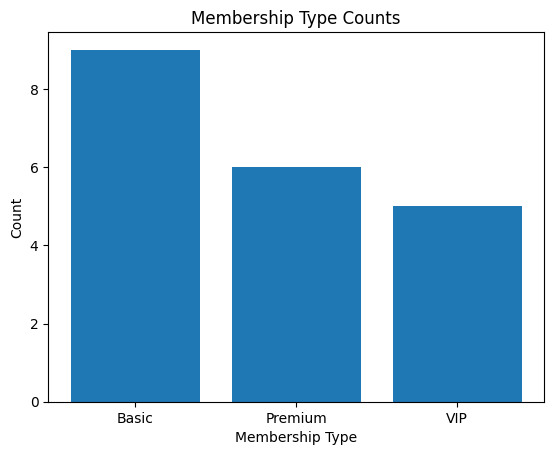

In [53]:
# Create a barchart that shows the amount of memberships
membership_counts = cate_df['membership_type'].value_counts()

plt.figure()
plt.bar(membership_counts.index, membership_counts.values)
plt.xlabel('Membership Type')
plt.ylabel('Count')
plt.title("Membership Type Counts")
plt.show()

15 Bar Chart for average numeric value by category

Create a barchart for the average numeric value by category, uses the same process as before, except the data you are inputting into the barchart is created byusign .groupby() and multiply by another column and a aggeregation function

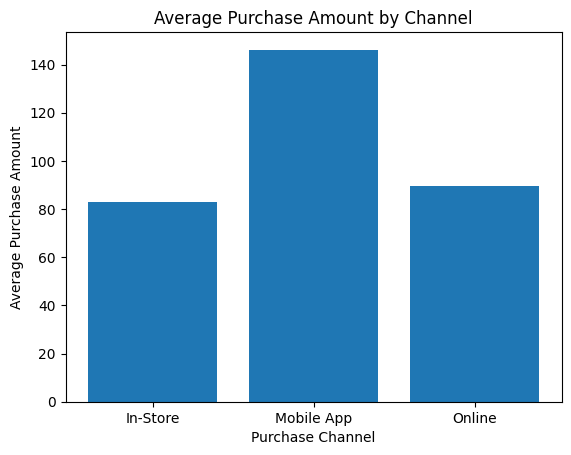

In [54]:
avg_purchase_by_channel = cate_df.groupby("purchase_channel")["purchase_amount"].mean()

plt.figure()
plt.bar(avg_purchase_by_channel.index, avg_purchase_by_channel.values)
plt.xlabel("Purchase Channel")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase Amount by Channel")
plt.show()

16 Find the most common category

To find the most common category you need to use the function .mode()

In [55]:
# Find the most common in the payment_method
cate_df["payment_method"].mode()

0    Credit Card
Name: payment_method, dtype: object

17 Fill the missing categorical values

Filling in the missing categorical values takes the .fillna() function

In [56]:
# Fill in the region column with unknown
cate_df["region"] = cate_df["region"].fillna("Unknown")

18 Convert text column to category type

To convert text columns into a category type you can use the function of .astype() and then passing the argument of the type being "category"

In [57]:
# Convert the membership_type into the category type
cate_df["membership_type"] = cate_df["membership_type"].astype("category")

In [58]:
# To convert the whole dataframe you can use a for loop

for col in category_cols:
    cate_df[col] = cate_df[col].astype('category')

19 Encode Catergories for modeling

For machine learning some of the categories need to be turned in numbers. This could be done by using the function pd.get_dummies() then passing the argument of a column

In [59]:
# Convert the membership type col into numbers
pd.get_dummies(df["membership_type"])

,Basic,Premium,VIP
0,True,False,False
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False
5,False,True,False
6,False,False,True
7,True,False,False
8,False,True,False
9,True,False,False


In [60]:
# To convert multiple columns
encoded_df = pd.get_dummies(
    df,
    columns=["membership_type", "purchase_channel", "payment_method"],
    drop_first=True
)

encoded_df.head()

,customer_id,gender,age_group,region,satisfaction_rating,returned_item,purchase_amount,membership_type_Premium,membership_type_VIP,purchase_channel_Mobile App,purchase_channel_Online,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal
0,1001,Female,18-24,West,High,No,45.99,False,False,False,True,True,False,False
1,1002,Male,25-34,South,Medium,No,120.50,True,False,False,False,False,True,False
2,1003,Female,25-34,West,Medium,Yes,62.75,False,False,False,True,False,False,True
3,1004,Male,35-44,East,High,No,210.00,False,True,True,False,True,False,False
4,1005,Female,18-24,North,Low,Yes,30.25,False,False,False,True,False,True,False


20 Ordered Categorical Values

Categories some times have a natural order so you can use that to order the dataframe.

In [61]:
rating_order = ["Low", "Medium", "High"]

df["satisfaction_rating"] = pd.Categorical(
    df["satisfaction_rating"],
    categories=rating_order,
    ordered=True
)